# Final Consumer Complaint Classifier — Transformer on 60,000 Records

This is the final scaling notebook. The pilot notebook already compared SimpleRNN, LSTM, GRU, and a fine-tuned Transformer on 15,999 records. The Transformer won that controlled comparison, so this notebook trains **only DistilBERT** on a larger stratified sample of **60,000 complaints**.

## Kaggle setup
1. Add dataset `shashwatwork/consume-complaints-dataset-fo-nlp`.
2. Enable GPU and Internet.
3. Run all cells from top to bottom.

This notebook uses PyTorch only; it does not import TensorFlow or Keras.

## 1. Install only missing packages

In [2]:
import importlib.util, subprocess, sys
requirements = [
    ("transformers", "transformers>=4.46,<5"),
    ("accelerate", "accelerate>=0.34,<2"),
    ("gradio", "gradio>=5,<7"),
]
missing = [req for name, req in requirements if importlib.util.find_spec(name) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("Installed:", missing)
else:
    print("All required packages are already installed.")

All required packages are already installed.


## 2. Imports and hardware check

In [3]:
import os, re, gc, glob, json, random, inspect, shutil, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
import joblib
import torch
import transformers
from torch import nn
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

warnings.filterwarnings("ignore")
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()): print(f"GPU {i}:", torch.cuda.get_device_name(i))

PyTorch: 2.10.0+cu128
Transformers: 5.0.0
CUDA available: True
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


## 3. Configuration

In [4]:
FINAL_ROWS = 60_000
TEST_SIZE = 0.15
VALIDATION_SIZE = 0.15
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 192
EPOCHS = 2
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
GRADIENT_ACCUMULATION_STEPS = 2
LEARNING_RATE = 2e-5
WORKING_DIR = Path('/kaggle/working/consumer_complaint_transformer_final_60k')
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print("Output:", WORKING_DIR)

Output: /kaggle/working/consumer_complaint_transformer_final_60k


## 4. Detect the dataset file and columns

In [5]:
TEXT_CANDIDATES = ["consumer complaint narrative","complaint narrative","consumer_complaint_narrative","complaint_text","narrative","complaint","text"]
LABEL_CANDIDATES = ["product","category","complaint category","complaint_category","label"]
def norm(name): return re.sub(r"[^a-z0-9]+", " ", str(name).strip().lower()).strip()
def choose(columns, candidates):
    mapping = {norm(c): c for c in columns}
    for candidate in candidates:
        if norm(candidate) in mapping: return mapping[norm(candidate)]
    for original in columns:
        for candidate in candidates:
            if norm(candidate) in norm(original) or norm(original) in norm(candidate): return original
    return None
csv_files = sorted(glob.glob('/kaggle/input/**/*.csv', recursive=True))
if not csv_files: raise FileNotFoundError('Add the Kaggle dataset first.')
valid=[]
for path in csv_files:
    try:
        preview = pd.read_csv(path, nrows=5, encoding_errors='ignore')
        t, y = choose(preview.columns, TEXT_CANDIDATES), choose(preview.columns, LABEL_CANDIDATES)
        if t and y: valid.append((path,t,y))
    except Exception: pass
if not valid: raise ValueError('Could not detect the complaint text and label columns.')
DATA_PATH, TEXT_COLUMN, LABEL_COLUMN = valid[0]
print('File:', DATA_PATH)
print('Text column:', TEXT_COLUMN)
print('Label column:', LABEL_COLUMN)

File: /kaggle/input/datasets/shashwatwork/consume-complaints-dataset-fo-nlp/complaints_processed.csv
Text column: narrative
Label column: product


## 5. Load and clean the complete dataset

In [6]:
full_df = pd.read_csv(DATA_PATH, usecols=[TEXT_COLUMN, LABEL_COLUMN], encoding_errors='ignore', low_memory=False)
df = full_df.rename(columns={TEXT_COLUMN:'text', LABEL_COLUMN:'label'}).copy()
df = df.dropna(subset=['text','label'])
df['text'] = df['text'].astype(str).str.strip()
df['label'] = df['label'].astype('string').str.strip()
df = df[(df['text'].str.len()>10) & (df['label'].str.len()>0)]
df = df.drop_duplicates(subset=['text','label']).reset_index(drop=True)
print('Cleaned rows:', f'{len(df):,}')
print('Classes:', df['label'].nunique())
full_counts = df['label'].value_counts()
display(full_counts.to_frame('full_cleaned_count'))
display(df.head())

Cleaned rows: 124,620
Classes: 5


,full_cleaned_count
label,
credit_reporting,56276
debt_collection,21104
mortgages_and_loans,18757
credit_card,15022
retail_banking,13461


,label,text
0,credit_card,purchase order day shipping amount receive pro...
1,credit_card,forwarded message date tue subject please inve...
2,retail_banking,forwarded message cc sent friday pdt subject f...
3,credit_reporting,payment history missing credit report speciali...
4,credit_reporting,payment history missing credit report made mis...


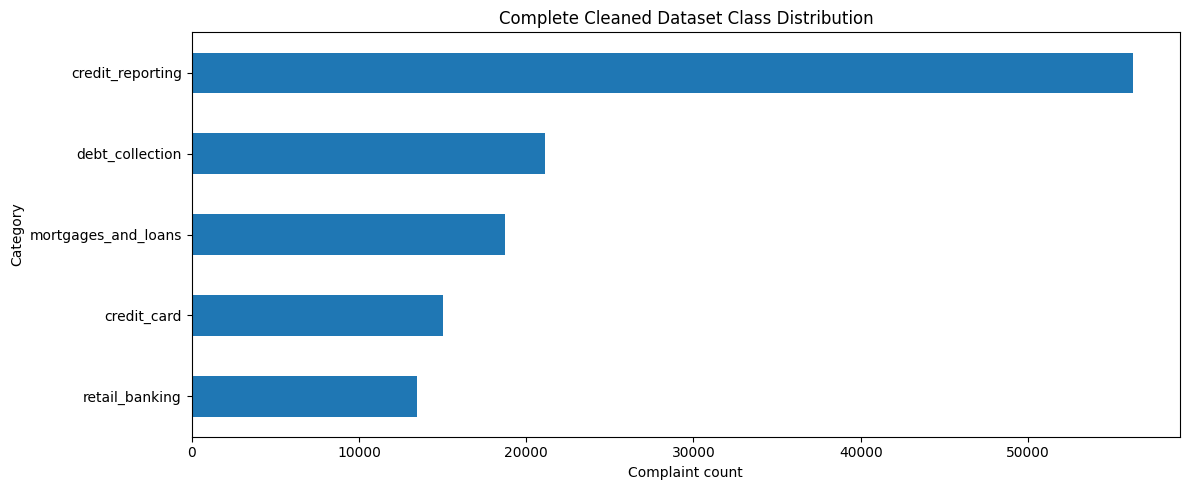

In [7]:
plt.figure(figsize=(12, max(5, 0.55*len(full_counts))))
full_counts.sort_values().plot(kind='barh')
plt.title('Complete Cleaned Dataset Class Distribution')
plt.xlabel('Complaint count'); plt.ylabel('Category'); plt.tight_layout(); plt.show()

## 6. Select exactly 60,000 records with stratification

In [8]:
if len(df) < FINAL_ROWS: raise ValueError(f'Only {len(df):,} cleaned rows are available.')
model_df, _ = train_test_split(df, train_size=FINAL_ROWS, stratify=df['label'], random_state=SEED)
model_df = model_df.reset_index(drop=True)
print('Modeling rows:', f'{len(model_df):,}')
display(model_df['label'].value_counts().to_frame('modeling_count'))
assert len(model_df) == 60_000

Modeling rows: 60,000


,modeling_count
label,
credit_reporting,27095
debt_collection,10161
mortgages_and_loans,9031
credit_card,7232
retail_banking,6481


## 7. Normalize text and encode labels

In [9]:
def normalize_text(text):
    text = re.sub(r"\b[xX]{2,}\b", " redacted ", str(text))
    return re.sub(r"\s+", " ", text).strip()
model_df['text_transformer'] = model_df['text'].map(normalize_text)
label_encoder = LabelEncoder()
model_df['label_id'] = label_encoder.fit_transform(model_df['label'])
class_names = label_encoder.classes_.tolist()
num_classes = len(class_names)
display(pd.DataFrame({'label_id':range(num_classes),'category':class_names}))

,label_id,category
0,0,credit_card
1,1,credit_reporting
2,2,debt_collection
3,3,mortgages_and_loans
4,4,retail_banking


## 8. Split into 42,000 train, 9,000 validation, and 9,000 test records

In [10]:
train_df, temp_df = train_test_split(model_df, test_size=TEST_SIZE+VALIDATION_SIZE, stratify=model_df['label_id'], random_state=SEED)
relative_test = TEST_SIZE/(TEST_SIZE+VALIDATION_SIZE)
validation_df, test_df = train_test_split(temp_df, test_size=relative_test, stratify=temp_df['label_id'], random_state=SEED)
train_df=train_df.reset_index(drop=True); validation_df=validation_df.reset_index(drop=True); test_df=test_df.reset_index(drop=True)
y_train=train_df['label_id'].to_numpy(); y_test=test_df['label_id'].to_numpy()
print('Train:', f'{len(train_df):,}'); print('Validation:', f'{len(validation_df):,}'); print('Test:', f'{len(test_df):,}')
assert (len(train_df),len(validation_df),len(test_df)) == (42000,9000,9000)

Train: 42,000
Validation: 9,000
Test: 9,000


## 9. Class weights

In [11]:
class_ids = np.arange(num_classes)
class_weight_values = compute_class_weight(class_weight='balanced', classes=class_ids, y=y_train)
class_weights_tensor = torch.tensor(class_weight_values, dtype=torch.float32)
display(pd.DataFrame({'label_id':class_ids,'category':class_names,'class_weight':class_weight_values}))

,label_id,category,class_weight
0,0,credit_card,1.659423
1,1,credit_reporting,0.442898
2,2,debt_collection,1.180936
3,3,mortgages_and_loans,1.328693
4,4,retail_banking,1.851444


## 10. Memory-efficient PyTorch dataset and batch tokenizer

In [12]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
class ComplaintDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts.astype(str).tolist(); self.labels = labels.astype(int).tolist()
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return {'text':self.texts[idx], 'labels':self.labels[idx]}
class BatchCollator:
    def __init__(self, tokenizer, max_length): self.tokenizer=tokenizer; self.max_length=max_length
    def __call__(self, features):
        texts=[f['text'] for f in features]
        labels=torch.tensor([f['labels'] for f in features], dtype=torch.long)
        batch=self.tokenizer(texts, padding=True, truncation=True, max_length=self.max_length, return_tensors='pt')
        batch['labels']=labels
        return batch
train_dataset=ComplaintDataset(train_df['text_transformer'],train_df['label_id'])
validation_dataset=ComplaintDataset(validation_df['text_transformer'],validation_df['label_id'])
test_dataset=ComplaintDataset(test_df['text_transformer'],test_df['label_id'])
data_collator=BatchCollator(tokenizer,MAX_LENGTH)
print(len(train_dataset),len(validation_dataset),len(test_dataset))

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

42000 9000 9000


## 11. Load DistilBERT

In [13]:
id2label={i:label for i,label in enumerate(class_names)}
label2id={label:i for i,label in enumerate(class_names)}
model=AutoModelForSequenceClassification.from_pretrained(MODEL_NAME,num_labels=num_classes,id2label=id2label,label2id=label2id)
print('Loaded:',MODEL_NAME)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded: distilbert-base-uncased


## 12. Metrics and weighted Trainer

In [14]:
def calculate_metrics(eval_prediction):
    logits, labels = eval_prediction
    predictions=np.argmax(logits,axis=1)
    pm,rm,fm,_=precision_recall_fscore_support(labels,predictions,average='macro',zero_division=0)
    pw,rw,fw,_=precision_recall_fscore_support(labels,predictions,average='weighted',zero_division=0)
    return {'accuracy':accuracy_score(labels,predictions),'precision_macro':pm,'recall_macro':rm,'f1_macro':fm,'precision_weighted':pw,'recall_weighted':rw,'f1_weighted':fw}
class WeightedTrainer(Trainer):
    def __init__(self,*args,class_weights=None,**kwargs):
        super().__init__(*args,**kwargs); self.class_weights=class_weights
    def compute_loss(self,model,inputs,return_outputs=False,num_items_in_batch=None):
        labels=inputs.pop('labels'); outputs=model(**inputs); logits=outputs.logits
        loss=nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))(logits,labels)
        return (loss,outputs) if return_outputs else loss

## 13. Configure training

In [15]:
args_values=dict(
    output_dir=str(WORKING_DIR/'checkpoints'), num_train_epochs=EPOCHS, learning_rate=LEARNING_RATE,
    per_device_train_batch_size=TRAIN_BATCH_SIZE, per_device_eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS, weight_decay=0.01, warmup_ratio=0.1,
    logging_steps=100, save_strategy='epoch', load_best_model_at_end=True, metric_for_best_model='f1_macro',
    greater_is_better=True, save_total_limit=1, report_to='none', remove_unused_columns=False,
    fp16=torch.cuda.is_available(), seed=SEED, data_seed=SEED,
)
if 'eval_strategy' in inspect.signature(TrainingArguments.__init__).parameters: args_values['eval_strategy']='epoch'
else: args_values['evaluation_strategy']='epoch'
training_args=TrainingArguments(**args_values)
trainer_values=dict(model=model,args=training_args,train_dataset=train_dataset,eval_dataset=validation_dataset,data_collator=data_collator,compute_metrics=calculate_metrics,class_weights=class_weights_tensor)
if 'processing_class' in inspect.signature(Trainer.__init__).parameters: trainer_values['processing_class']=tokenizer
else: trainer_values['tokenizer']=tokenizer
trainer=WeightedTrainer(**trainer_values)
print('Trainer ready.')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainer ready.


## 14. Train the final model
This is the longest cell. If CUDA runs out of memory, set `TRAIN_BATCH_SIZE = 8`, restart, and rerun.

In [16]:
training_result=trainer.train()
training_result

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
1,1.003089,0.489877,0.820667,0.795556,0.833996,0.812445,0.829977,0.820667,0.822411
2,0.850662,0.469907,0.826111,0.800961,0.842101,0.818839,0.836558,0.826111,0.828011


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1314, training_loss=1.1683042800589785, metrics={'train_runtime': 947.0567, 'train_samples_per_second': 88.696, 'train_steps_per_second': 1.387, 'total_flos': 4164397557280800.0, 'train_loss': 1.1683042800589785, 'epoch': 2.0})

## 15. Test-set evaluation

In [17]:
test_output=trainer.predict(test_dataset)
test_logits=test_output.predictions; test_labels=test_output.label_ids
test_probabilities=torch.softmax(torch.tensor(test_logits),dim=1).cpu().numpy()
test_predictions=np.argmax(test_probabilities,axis=1)
final_metrics=calculate_metrics((test_logits,test_labels))
final_metrics_df=pd.DataFrame([final_metrics])
display(final_metrics_df.style.format({c:'{:.4f}' for c in final_metrics_df.columns}))
print(classification_report(test_labels,test_predictions,target_names=class_names,zero_division=0))

,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,0.8314,0.8039,0.8491,0.8233,0.8428,0.8314,0.8333


                     precision    recall  f1-score   support

        credit_card       0.72      0.84      0.77      1085
   credit_reporting       0.93      0.80      0.86      4065
    debt_collection       0.74      0.82      0.78      1524
mortgages_and_loans       0.80      0.88      0.84      1354
     retail_banking       0.83      0.91      0.87       972

           accuracy                           0.83      9000
          macro avg       0.80      0.85      0.82      9000
       weighted avg       0.84      0.83      0.83      9000



## 16. Confusion matrix

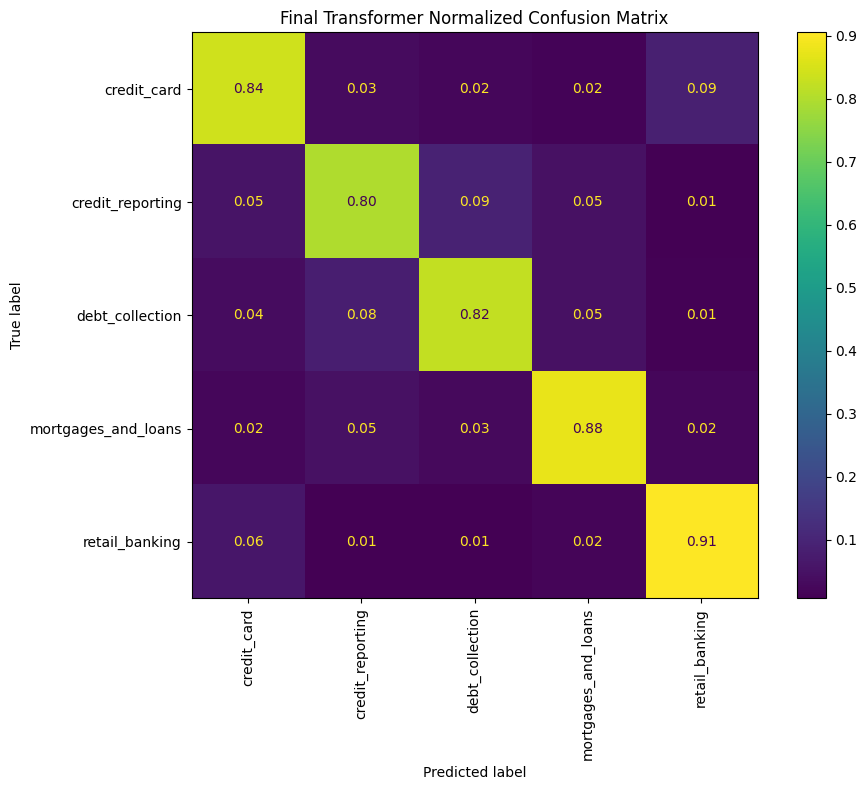

In [18]:
matrix=confusion_matrix(test_labels,test_predictions,normalize='true')
fig,ax=plt.subplots(figsize=(max(10,.8*num_classes),max(8,.7*num_classes)))
ConfusionMatrixDisplay(matrix,display_labels=class_names).plot(ax=ax,xticks_rotation=90,values_format='.2f',colorbar=True)
ax.set_title('Final Transformer Normalized Confusion Matrix'); plt.tight_layout(); plt.show()

## 17. Error analysis

In [19]:
error_analysis=test_df[['text','label']].copy()
error_analysis['predicted_label']=label_encoder.inverse_transform(test_predictions)
error_analysis['confidence']=test_probabilities.max(axis=1)
error_analysis['correct']=error_analysis['label']==error_analysis['predicted_label']
display(error_analysis[~error_analysis['correct']].sort_values('confidence',ascending=False).head(25))

,text,label,predicted_label,confidence,correct
7777,back started refinance current mortgage anothe...,credit_reporting,mortgages_and_loans,0.983386,False
2336,contacted uplift last week regard loan explain...,credit_card,mortgages_and_loans,0.982020,False
6794,beginning global pandemic spouse offered forbe...,credit_reporting,mortgages_and_loans,0.980216,False
8652,notified loan sold servicing transferred doven...,retail_banking,mortgages_and_loans,0.979519,False
976,made aware pnc bank placed hold checking accou...,credit_card,retail_banking,0.978456,False
2455,trying connect pnc account app pnc isnt lettin...,mortgages_and_loans,retail_banking,0.978269,False
8545,purchased vehicle ally auto finance company go...,credit_reporting,mortgages_and_loans,0.978234,False
3031,hello dear sir madam huge amount fraudulent tr...,credit_card,retail_banking,0.978229,False
4903,submitted public service forgiveness loan form...,debt_collection,mortgages_and_loans,0.978027,False
4518,im trouble opening account due victim fraud so...,credit_reporting,retail_banking,0.977989,False


## 18. Save final model and artifacts

In [20]:
FINAL_MODEL_DIR=WORKING_DIR/'fine_tuned_transformer'
trainer.save_model(str(FINAL_MODEL_DIR)); tokenizer.save_pretrained(str(FINAL_MODEL_DIR))
joblib.dump(label_encoder,WORKING_DIR/'label_encoder.joblib')
final_metrics_df.to_csv(WORKING_DIR/'final_transformer_metrics.csv',index=False)
error_analysis.to_csv(WORKING_DIR/'final_error_analysis.csv',index=False)
model_df['label'].value_counts().rename_axis('category').reset_index(name='count').to_csv(WORKING_DIR/'final_60k_class_distribution.csv',index=False)
config={'experiment_type':'final_transformer_60k','seed':SEED,'modeling_rows':len(model_df),'training_rows':len(train_df),'validation_rows':len(validation_df),'test_rows':len(test_df),'class_names':class_names,'base_model':MODEL_NAME,'max_length':MAX_LENGTH,'epochs':EPOCHS,'train_batch_size':TRAIN_BATCH_SIZE,'learning_rate':LEARNING_RATE,'selection_basis':'Transformer won the controlled 15,999-row pilot comparison.','final_metrics':{k:float(v) for k,v in final_metrics.items()},'saved_model_path':str(FINAL_MODEL_DIR)}
with open(WORKING_DIR/'experiment_config.json','w',encoding='utf-8') as f: json.dump(config,f,indent=2,ensure_ascii=False)
print('Saved files:')
for p in sorted(WORKING_DIR.rglob('*')):
    if p.is_file(): print(p.relative_to(WORKING_DIR))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved files:
checkpoints/checkpoint-1314/config.json
checkpoints/checkpoint-1314/model.safetensors
checkpoints/checkpoint-1314/optimizer.pt
checkpoints/checkpoint-1314/rng_state.pth
checkpoints/checkpoint-1314/scaler.pt
checkpoints/checkpoint-1314/scheduler.pt
checkpoints/checkpoint-1314/tokenizer.json
checkpoints/checkpoint-1314/tokenizer_config.json
checkpoints/checkpoint-1314/trainer_state.json
checkpoints/checkpoint-1314/training_args.bin
experiment_config.json
final_60k_class_distribution.csv
final_error_analysis.csv
final_transformer_metrics.csv
fine_tuned_transformer/config.json
fine_tuned_transformer/model.safetensors
fine_tuned_transformer/tokenizer.json
fine_tuned_transformer/tokenizer_config.json
fine_tuned_transformer/training_args.bin
label_encoder.joblib


## 19. Zip final artifacts

In [21]:
archive_path=shutil.make_archive('/kaggle/working/consumer_complaint_transformer_final_60k','zip',root_dir=str(WORKING_DIR))
print('Download from Kaggle Output:',archive_path)

Download from Kaggle Output: /kaggle/working/consumer_complaint_transformer_final_60k.zip


In [23]:
from pathlib import Path
import shutil

source_dir = Path(
    "/kaggle/working/consumer_complaint_transformer_final_60k"
)

deployment_dir = Path(
    "/kaggle/working/consumer_complaint_deployment"
)

# Remove an older deployment folder if it exists.
if deployment_dir.exists():
    shutil.rmtree(deployment_dir)

deployment_dir.mkdir(parents=True)

# Copy only the final trained model and tokenizer.
final_model_dir = source_dir / "fine_tuned_transformer"

if not final_model_dir.exists():
    raise FileNotFoundError(
        f"Final model folder not found: {final_model_dir}"
    )

shutil.copytree(
    final_model_dir,
    deployment_dir / "fine_tuned_transformer"
)

# Copy only the useful small project files.
optional_files = [
    "experiment_config.json",
    "final_transformer_metrics.csv",
    "final_60k_class_distribution.csv",
    "label_encoder.joblib",
]

for filename in optional_files:
    source_file = source_dir / filename

    if source_file.exists():
        shutil.copy2(
            source_file,
            deployment_dir / filename
        )

# Create a deployment-only archive.
deployment_zip = shutil.make_archive(
    "/kaggle/working/consumer_complaint_deployment",
    "zip",
    root_dir=str(deployment_dir),
)

print("Deployment ZIP created:")
print(deployment_zip)
print(
    "Size:",
    round(Path(deployment_zip).stat().st_size / 1024**2, 2),
    "MB"
)

Deployment ZIP created:
/kaggle/working/consumer_complaint_deployment.zip
Size: 235.76 MB


## 20. Gradio deployment — run last

In [ ]:
import gradio as gr
deployment_tokenizer=AutoTokenizer.from_pretrained(str(FINAL_MODEL_DIR))
deployment_model=AutoModelForSequenceClassification.from_pretrained(str(FINAL_MODEL_DIR))
deployment_model.eval(); deployment_device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'); deployment_model.to(deployment_device)
def predict_complaint(text):
    encoded=deployment_tokenizer(normalize_text(text),return_tensors='pt',truncation=True,max_length=MAX_LENGTH)
    encoded={k:v.to(deployment_device) for k,v in encoded.items()}
    with torch.no_grad(): probabilities=torch.softmax(deployment_model(**encoded).logits,dim=1)[0].cpu().numpy()
    best=int(np.argmax(probabilities)); scores={label:float(p) for label,p in zip(class_names,probabilities)}
    return scores,f'Predicted category: {class_names[best]}\nConfidence: {probabilities[best]:.2%}'
demo=gr.Interface(fn=predict_complaint,inputs=gr.Textbox(lines=8,label='Consumer complaint narrative'),outputs=[gr.Label(num_top_classes=3,label='Category probabilities'),gr.Textbox(label='Prediction')],title='Consumer Complaint Classification',description='Final DistilBERT model trained on 60,000 records.',examples=[["I found accounts on my credit report that are not mine."],["The mortgage company charged a late fee although I paid on time."],["A debt collector keeps calling about a debt I already paid."]])
demo.launch(share=True,debug=False)

## Report wording

> A controlled pilot comparison was first performed using 15,999 complaints. SimpleRNN, LSTM, GRU, and a fine-tuned Transformer were trained and evaluated on the same split. The Transformer achieved the highest macro F1-score and was selected as the best architecture. The selected DistilBERT Transformer was then trained and evaluated on a larger stratified dataset containing 60,000 complaints, divided into 42,000 training records, 9,000 validation records, and 9,000 untouched test records.

The pilot is the fair four-model comparison. The 60,000-record experiment is the final scaled Transformer result.